## This program calculates $\theta_*$ using the parameters $w_b$, $w_m$, and $h$, and then uses an MCMC (Emcee) method to perform the statistical analysis

In [ ]:
#Importing modules
import numpy as np
import matplotlib.pyplot as plt 
from fonction import DHrd, trapezeVect, DMrd,DHrdw0wa, DMrdw0wa
import emcee
import corner
import scipy.stats as st

In [2]:
# Cosmological constants 
z_star = 1089.0
omega_g = 2.47e-5   # photons
omega_nu = 1.70e-5  # neutrinos
omega_r = omega_g + omega_nu
c = 299792.458      # km/s
h = 0.6749
wm = 0.14208
wb = 0.02223
w0 = -1
wa = 0

def trapeze_vect(f, a, b, n):
    x = np.linspace(a, b, n + 1)
    y = f(x)
    hstep = (b - a) / n
    return hstep * np.sum((y[:-1] + y[1:]) / 2.0)

# We now pass the free parameters as arguments to each function

def E(z, w0, wa, omega_cb, h):
    omega_lambda = h**2 - omega_cb - omega_r
    de_dark = (1.0 + z)**(3.0 * (1.0 + w0 + wa)) * np.exp(-3.0 * wa * z / (1.0 + z))
    return np.sqrt(omega_cb * (1.0 + z)**3 + omega_r * (1.0 + z)**4 + omega_lambda * de_dark)

def H(z, w0, wa, omega_cb, h):
    return 100.0  * E(z, w0, wa, omega_cb, h)

def R(z, omega_b):
    return 3.0 * omega_b / (4.0 * omega_g * (1.0 + z))

def c_s(z, omega_b):
    return c / np.sqrt(3.0 * (1.0 + R(z, omega_b)))

def chi_star(zs, w0, wa, omega_cb, h, n=200000):
    return trapeze_vect(lambda z: c / H(z, w0, wa, omega_cb, h), 0.0, zs, n)

def rs_star(zs, w0, wa, omega_b, omega_cb, h, zmax=1.0e7, n=200000):
    return trapeze_vect(lambda z: c_s(z, omega_b) / H(z, w0, wa, omega_cb, h), zs, zmax, n)

def theta_star(zs, w0, wa, omega_b, omega_cb, h, n=200000, zmax=1.0e7):
    rs = rs_star(zs, w0, wa, omega_b, omega_cb, h, zmax=zmax, n=n)
    chi = chi_star(zs, w0, wa, omega_cb, h, n=n)
    theta = rs / chi
    return rs, theta
rs,theta = theta_star(z_star,w0,wa,wb,wm,h)
print("rs = ", rs)
print("theta =", theta)


rs =  144.77943777869322
theta = 0.01041564749697014


$\chi^2$DESI

In [4]:
redshift = np.array([0.510,0.706,0.934,1.321,1.484,2.330])
DMrd_data = np.array([13.588,17.351,21.576,27.601,30.512,38.988])
DHrd_data = np.array([21.863,19.455,17.641,14.176,12.817,8.632])
IDMrd = np.array([0.167,0.177,0.152,0.318,0.760,0.531])
IDHrd = np.array([0.425,0.330,0.193,0.221,0.516,0.101])
rMH = np.array([-0.459,-0.404,-0.416,-0.434,-0.500,-0.431])

n = len(IDMrd)
z = len(redshift)
size = 2*n
size2 = 2*z
C = np.zeros((size,size))

for i in range (n) :
	C[i*2,i*2] = IDMrd[i]**2
	C[i*2+1,i*2+1] = IDHrd[i]**2
	C[i*2,i*2+1] = rMH[i]*IDMrd[i]*IDHrd[i]
	C[i*2+1,i*2] = rMH[i]*IDMrd[i]*IDHrd[i]
Cinv=np.linalg.inv(C)
md = np.zeros((size2,1))

def get_chi2_DESI(hrd, Om, w0, wa):
    Ol = 1.0 - Om
    n_data = len(redshift)
    DHrd_model = DHrdw0wa(redshift, hrd, Om, Ol, w0, wa)
    DMrd_model = np.array([DMrdw0wa(zi, hrd, Om, Ol, w0, wa) for zi in redshift])
    md = np.zeros((n_data * 2, 1))
    for i in range(n_data):
        md[i*2, 0]   = DMrd_model[i] - DMrd_data[i]     
        md[i*2+1, 0] = DHrd_model[i] - DHrd_data[i]    
    chi2BAO = float(md.T @ Cinv @ md)
    return chi2BAO

[[ 0.027889   -0.03257753  0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [-0.03257753  0.180625    0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.031329   -0.02359764  0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.         -0.02359764  0.1089      0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.023104   -0.01220378
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.         -0.01220378  0.037249
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.101124   -0.03050065  0.          0.          0.          0.        ]

$\chi^2$ CMB

In [5]:
mu = np.array([0.01041,0.02223,0.14208])
Cov = 1e-9*np.array([[0.006621,0.12444,-1.1929],[0.12444,21.344,-94.001],[-1.1929,-94.001,1488.4]])
ICov = np.linalg.inv(Cov)

'\ndef log_prior(params):\n\tombh2, omh2, h,w0,wa = params\n\tif not (0.02162<ombh2<0.024  and 0.1356<omh2<0.1500 and 0.6466<h<0.7006 and -2<w0<-0.4 and -3<wa<1):\n\t\treturn -np.inf\n\ttheta_starTheo = theta_star(zstar,h,omh2,ombh2,w0,wa)\n\tXtheo = np.array([theta_starTheo,wb,wm])\n\tXmu = Xtheo-mu\n\tchi2CMB = float(Xmu.T@ICov@Xmu)\n\treturn -0.5*chi2CMB'

In [6]:
def log_prior(params):
    ombh2, omh2, h, w0, wa = params
    # Prior
    if (0.020 < ombh2 < 0.025 and
        0.120 < omh2  < 0.165 and
        0.60  < h     < 0.75 and
        -3.0 < w0 < 2 and 
        -5.0 < wa < 2):
        return 0.0 
    return -np.inf

def log_likelihood_batch(params_batch):
    params_batch = np.asarray(params_batch)
    if params_batch.ndim == 1:
        params_batch = params_batch.reshape(1, -1)
    nwalkers = params_batch.shape[0]
    loglikes = np.zeros(nwalkers)
    for i in range(nwalkers):
        ombh2, omh2, h, w0, wa = params_batch[i]
        wb = ombh2 
        wm = omh2    
        theta_starTheo = theta_star(z_star, w0, wa, wb, wm, h)[1]
        
        Xtheo = np.array([theta_starTheo, wb, wm])
        Xmu = Xtheo - mu
        chi2CMB = float(Xmu.T @ ICov @ Xmu)
        
        Om_theo = wm / (h**2)*
        rs_theo = rs_star(z_star, w0, wa, wb, wm, h)  
        hrd_theo = h * rs_theo
        
        chi2DESI = get_chi2_DESI(hrd_theo, Om_theo, w0, wa)
        chi2_total = chi2CMB + chi2DESI
        loglikes[i] = -0.5 * chi2_total
        
    return loglikes

def log_posterior_vectorized(params_batch):
    params_batch = np.asarray(params_batch)
    if params_batch.ndim == 1:
        params_batch = params_batch.reshape(1, -1)
    nwalkers = params_batch.shape[0]
    lp = np.zeros(nwalkers, dtype=np.float64)
    for i, p in enumerate(params_batch):
        lp[i] = log_prior(p)
    good_mask = np.isfinite(lp)
    if np.any(good_mask):
        likes = log_likelihood_batch(params_batch[good_mask])
        lp[good_mask] += likes
    return lp

In [7]:
#emcee
# Initial parameters: ombh2, omch2, h, w0, wa
initial_params = [0.02223, 0.14208, 0.67,-1,0 ]
nwalkers = 30
ndim = len(initial_params)
nsteps = 10000

# Initialize walkers around starting point
np.random.seed(42)
pos = initial_params + 1e-3 * np.random.randn(nwalkers, ndim)

nom_fichier_sauvegarde = "mcmc_desi_cmb_w0wa.h5"
backend = emcee.backends.HDFBackend(nom_fichier_sauvegarde)
backend.reset(nwalkers, ndim)
# Use the VECTORIZED log-probability function
sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_posterior_vectorized,  # <-- FAST vectorized version
    vectorize=True,
    backend=backend)

print("Running MCMC with omh2 as total matter parameter...")
sampler.run_mcmc(pos, nsteps, progress=True,store=True)
print("Extraction et exportation des données en format texte...")
samples = sampler.get_chain(discard=1000, flat=True)
#Data recording
header_colonnes = "ombh2    omh2    h    w0    wa"
nom_fichier_txt = "chaines_points_w0wa.txt"
np.savetxt(nom_fichier_txt, samples, header=header_colonnes, fmt="%.6f")

print(f"Succès ! Vos chaînes sont enregistrées dans : {nom_fichier_txt}")

Running MCMC with omh2 as total matter parameter...


C:\Users\louar\AppData\Local\Temp\ipykernel_5508\3617286747.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  chi2BAO = float(md.T @ Cinv @ md)
100%|██████████████████████████████████████████████████████████████████████████| 10000/10000 [5:53:27<00:00,  2.12s/it]


Extraction et exportation des données en format texte...
Succès ! Vos chaînes sont enregistrées dans : chaines_points_w0wa2.txt


C:\Users\louar\AppData\Local\Temp\ipykernel_22424\1305727076.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", frameon=True, facecolor='white', edgecolor='none', fontsize=11)


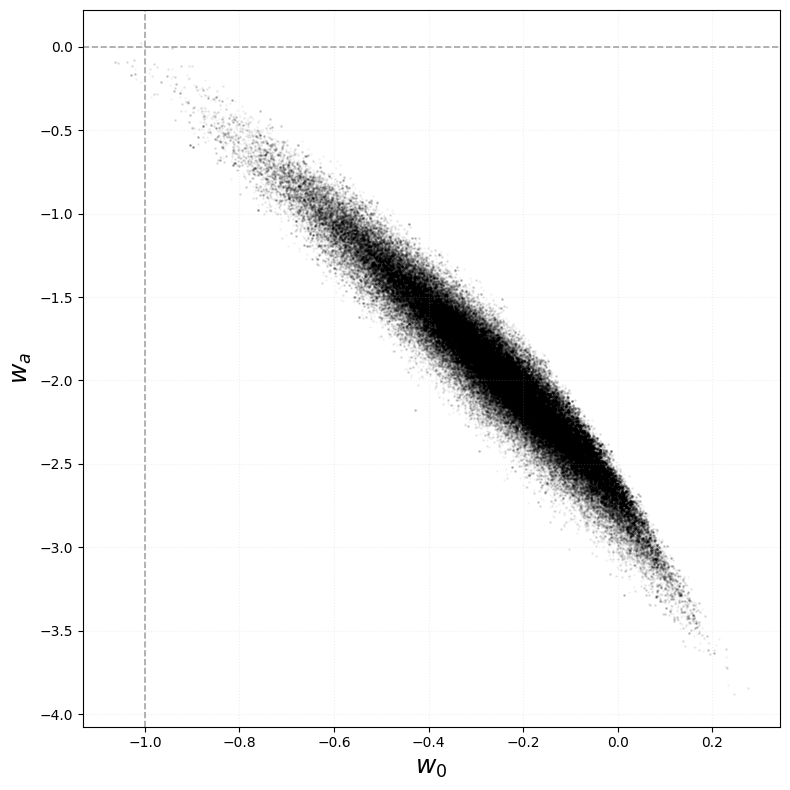

'\nw0wa_samples = samples[:, [3, 4]]\nfig = corner.corner(\n    w0wa_samples,\n    labels=[r"$w_0$", r"$w_a$"],\n    truths=[-1.0, 0.0],       \n    truth_color="red",\n    levels=[0.68, 0.95],      \n    smooth=1.0)\nplt.suptitle("Contours de confiance MCMC : $w_0$ vs $w_a$ (DESI DR2 + CMB)", fontsize=14)\nplt.show()'

In [8]:
nom_fichier_sauvegarde = "mcmc_desi_cmb_w0wa.h5"
reader = emcee.backends.HDFBackend(nom_fichier_sauvegarde, read_only=True)
samples = reader.get_chain(discard=int(0.3*nsteps), flat=True)
w0_points = samples[:, 3]  
wa_points = samples[:, 4]  
plt.figure(figsize=(8, 8))
plt.scatter(
    w0_points, wa_points,
    s=1,
    color='black',
    alpha=0.03,)
    #label="Points MCMC (DESI DR2 + CMB)")
plt.axvline(-1.0, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
plt.axhline(0.0, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
plt.xlabel(r"$w_0$", fontsize=18)
plt.ylabel(r"$w_a$", fontsize=18)
plt.grid(alpha=0.2, linestyle=':')
plt.legend(loc="upper right", frameon=True, facecolor='white', edgecolor='none', fontsize=11)
plt.tight_layout()
plt.savefig("w0waemcee.png", dpi=300)
plt.show()

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:  ()
    Data variables:
        ombh2    float64 8B 1.008
        omh2     float64 8B 1.008
        h        float64 8B 1.01
        w0       float64 8B 1.009
        wa       float64 8B 1.009
           mean        sd eti68_lb eti68_ub  ess_bulk  ess_tail r_hat  \
ombh2  0.022511  0.000131    0.022    0.023      4348      8937  1.01   
omh2    0.13886   0.00092     0.14     0.14      4277      7398  1.01   
h         0.627    0.0189     0.61     0.65      2930      3641  1.01   
w0       -0.277     0.199    -0.46   -0.083      2872      4101  1.01   
wa        -1.92      0.56     -2.5     -1.4      2927      4564  1.01   

      mcse_mean  mcse_sd  
ombh2     2e-06  2.3e-06  
omh2    1.4e-05  1.1e-05  
h       0.00037  0.00034  
w0       0.0039   0.0035  
wa        0.011    0.009  


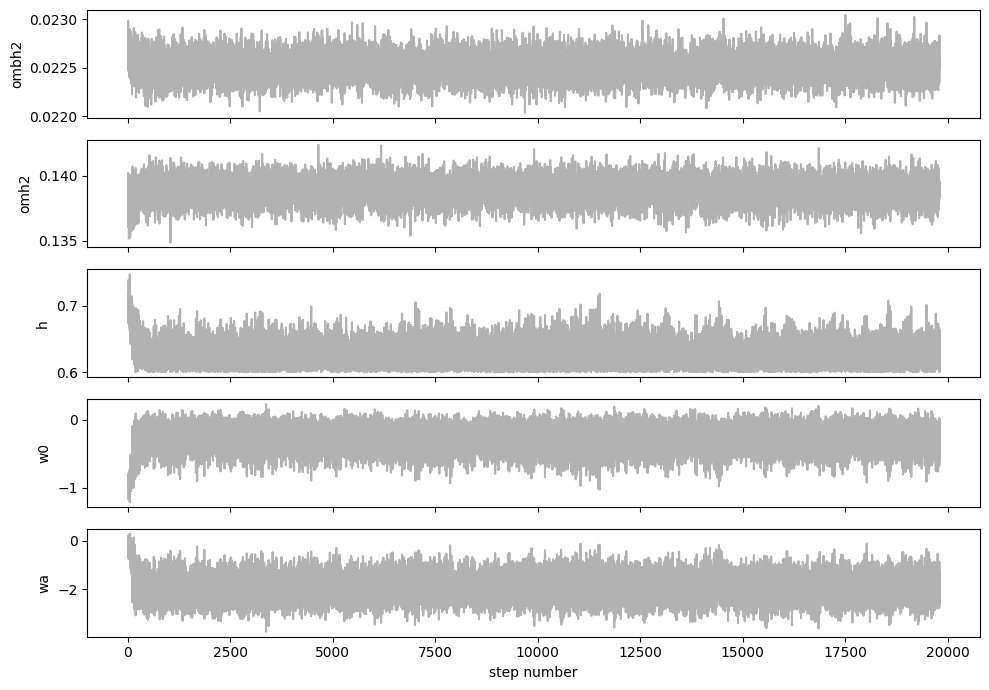

'import arviz as az\n\nidata = az.from_emcee(\n    sampler,\n    var_names=["ombh2", "omh2", "h", "w0", "wa"]\n)\n# Calcul du facteur de Gelman–Rubin (R-hat)\n# R-hat = sqrt(moyenne des variances / variance des moyennes)\n# R-hat ≈ 1 → bonne convergence du MCMC\n# R-hat > 1.1 → le MCMC n’a probablement pas encore convergé\nprint(az.rhat(idata))\nidata = az.from_emcee(reader, var_names=param_names)\n\n# Résumé complet : moyenne, std, HDI 94%, R-hat, ESS\nsummary = az.summary(idata, ci_prob=0.68)  # 0.68 = ±1σ équivalent\nprint(summary)\n#On peut aussi regarder l\'évolution des chaines\n# Analyze results\nsamples = sampler.get_chain(discard=100, thin=15, flat=True)\n\n# Plot traces\nfig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)\nfor i in range(ndim):\n    ax = axes[i]\n    ax.plot(samples[:, i], color="k", alpha=0.3)\n    ax.set_ylabel(["ombh2", "omh2", "h", "w0", "wa"][i])\naxes[-1].set_xlabel("step number")'

In [9]:
import arviz as az

param_names = ["ombh2", "omh2", "h", "w0", "wa"]
idata = az.from_emcee(sampler, var_names=param_names)
print(az.rhat(idata))

# Full summary: mean, standard deviation, HDI 68%, R-hat, ESS
summary = az.summary(idata, ci_prob=0.68)
print(summary)
samples = sampler.get_chain(discard=100, thin=15, flat=True)
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, i], color="k", alpha=0.3)
    ax.set_ylabel(param_names[i])
axes[-1].set_xlabel("step number")
plt.tight_layout()
plt.show()

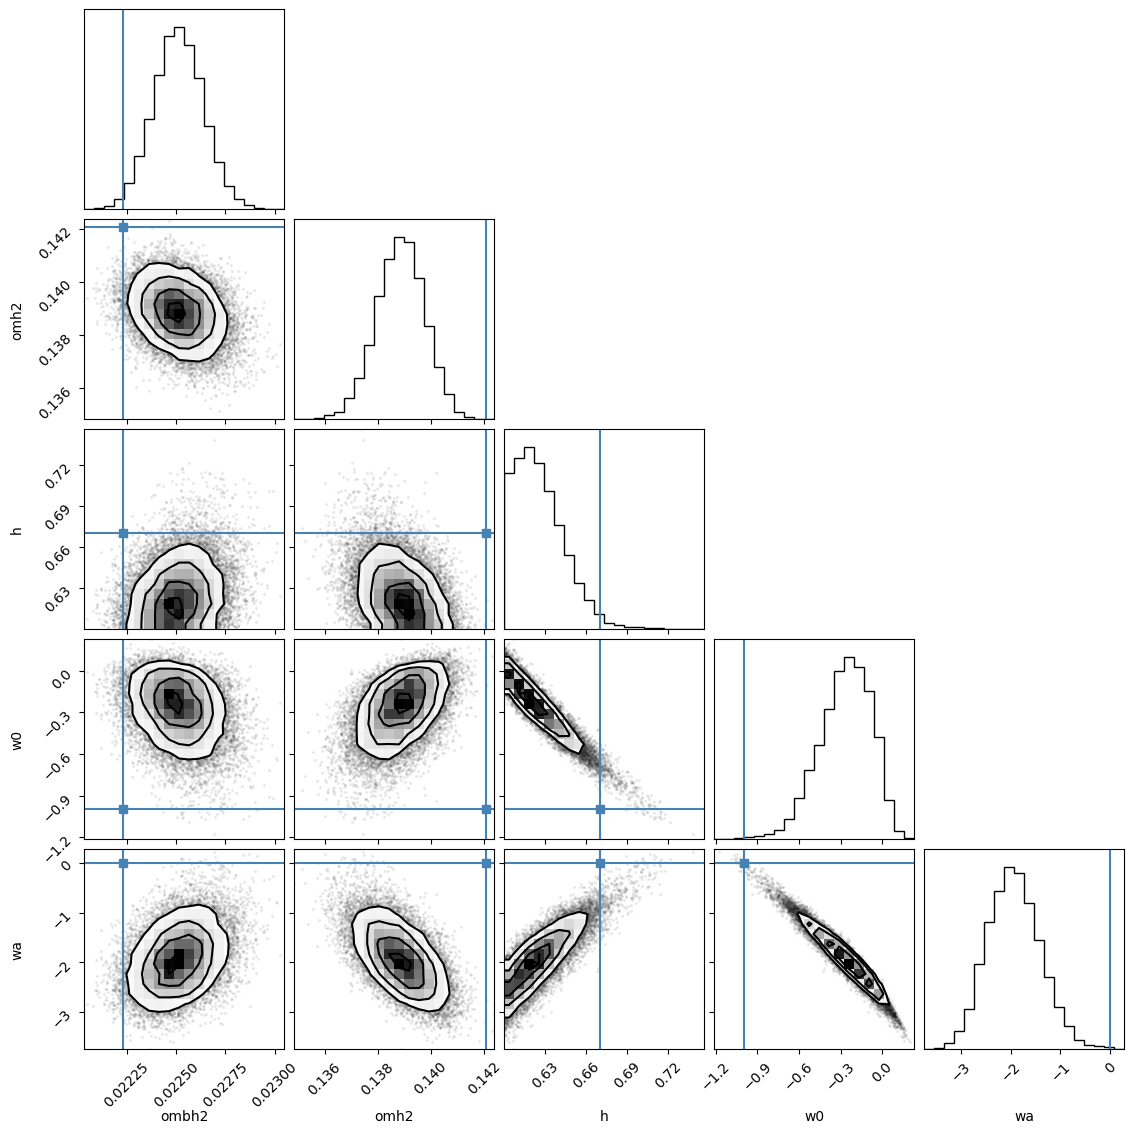

ombh2: 0.0225 +0.0001 -0.0001
omh2: 0.1389 +0.0009 -0.0009
h: 0.6237 +0.0207 -0.0155
w0: -0.2539 +0.1737 -0.2043
wa: -1.9573 +0.5478 -0.5072


In [10]:
# Corner plot
labels = [ "ombh2", "omh2", "h", "w0", "wa"]
fig = corner.corner(samples, labels=labels, truths=initial_params)

plt.show()

#Print best-fit parameters
for i in range(ndim):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    print(f"{labels[i]}: {mcmc[1]:.4f} +{mcmc[2]-mcmc[1]:.4f} -{mcmc[1]-mcmc[0]:.4f}")

Results for the posterior distributions of $w_0$ and $w_a$, from fits of the $w_0w_a$CDM model to DESI in combination with CMB 

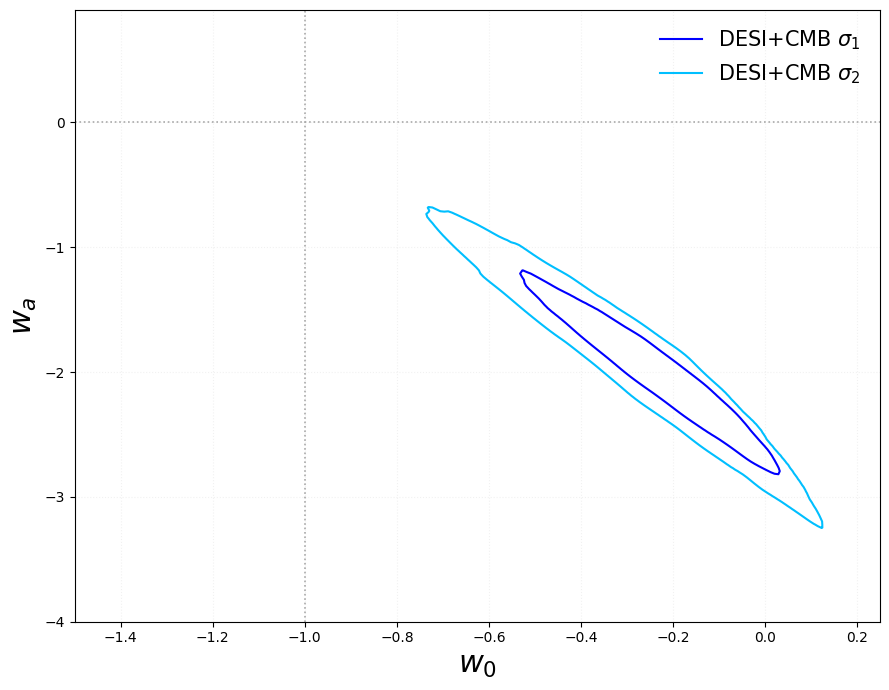

In [3]:
nom_fichier_txt = "chaines_points_w0wa.txt"
data = np.loadtxt(nom_fichier_txt)
total_lignes = data.shape[0]
discard_index = int(0.3 * total_lignes)
samples_filtres = data[discard_index:, :]
w0 = samples_filtres[:, 3]
wa = samples_filtres[:, 4]
w0_best = np.median(w0)
wa_best = np.median(wa)
xmin, xmax = -1.5, 0.2
ymin, ymax = -4.0, 1.0
X, Y = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
positions = np.vstack([X.ravel(), Y.ravel()])
values = np.vstack([w0, wa])
kernel = st.gaussian_kde(values)
Z = np.reshape(kernel(positions).T, X.shape)

def find_confidence_levels(z, levels=[0.68, 0.95]):
    z_sorted = np.sort(z.ravel())[::-1]
    integral = np.cumsum(z_sorted)
    integral /= integral[-1]
    
    contour_levels = []
    for level in levels:
        idx = np.where(integral >= level)[0][0]
        contour_levels.append(z_sorted[idx])
    return sorted(contour_levels)

levels_68_95 = find_confidence_levels(Z, levels=[0.68, 0.95])

plt.figure(figsize=(9, 7))
plt.axhline(0, color="darkgray", linestyle=":", linewidth=1.2)
plt.axvline(-1, color="darkgray", linestyle=":", linewidth=1.2)
contour_1sig = plt.contour(X, Y, Z, levels=[levels_68_95[1]], colors="blue", linewidths=1.5)
contour_2sig = plt.contour(X, Y, Z, levels=[levels_68_95[0]], colors="deepskyblue", linewidths=1.5)
lines = [plt.Line2D([0], [0], color="blue", linestyle="-", linewidth=1.5),plt.Line2D([0], [0], color="deepskyblue", linestyle="-", linewidth=1.5)]
labels = [r"DESI+CMB $\sigma_1$", r"DESI+CMB $\sigma_2$"]
plt.legend(lines, labels, loc="upper right", frameon=False, fontsize=15)
plt.xlim(-1.5, 0.25)
plt.ylim(-4.0, 0.9)
plt.xlabel("$w_0$", fontsize=22)
plt.ylabel("$w_a$", fontsize=22)
plt.grid(True, linestyle=":", alpha=0.3, color="lightgray")
plt.tight_layout()
#plt.savefig("contours_w0_wa_custom.pdf", dpi=300)
plt.show()